# TikTok Content Moderation: Classifying Claims vs. Opinions

---

## Project Overview

TikTok receives a large volume of user reports flagging videos as misleading or policy-violating. Each report has to be reviewed manually, which creates a backlog and slows response time on videos that actually contain factual claims (as opposed to personal opinions).

The business goal of this project is to build a machine learning pipeline that triages user-reported videos by predicting whether a video contains a **claim** (a statement presented as fact) or an **opinion** (a personal view). Claims carry higher moderation risk — they can spread misinformation — and should be prioritized for human review. Opinions are lower-priority.

## Objectives

1. **Inspect and profile** the raw dataset — schema, missingness, distributional shape, class balance.
2. **Explore relationships** between the target (`claim_status`) and engagement metrics, verified status, and author ban status.
3. **Validate key hypotheses statistically** using a two-sample t-test on view counts between verified and unverified accounts.
4. **Build an interpretable baseline** — logistic regression predicting verified status — to understand which features carry signal.
5. **Train production-grade classifiers** — Random Forest and XGBoost — to predict claim vs. opinion, with recall as the primary metric given the asymmetric cost of missing a claim.
6. **Evaluate on a held-out test set** and analyze feature importances to explain the model's behavior.

## Methodology

The analysis follows the **PACE framework** (Plan → Analyze → Construct → Execute) and is structured as four sequential phases in this notebook:

| Phase | Focus | Key Output |
|---|---|---|
| 1 | Data inspection & exploratory analysis | Profile of engagement patterns by claim status and ban status |
| 2 | Hypothesis testing | Two-sample t-test on view counts (verified vs. not verified) |
| 3 | Logistic regression | Interpretable baseline predicting `verified_status` |
| 4 | Tree-based classification | Random Forest + XGBoost predicting `claim_status`; final model evaluation |

## Success Metric

Primary: **Recall on the claim class.** The cost of a false negative (letting a claim video through unreviewed) is much higher than the cost of a false positive (routing an opinion video to a human moderator who then clears it). F1 is used as a tiebreaker.

## 1. Setup

Import all libraries used across the four phases upfront — data manipulation, visualization, statistical testing, and modeling.

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy import stats

# Preprocessing
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import resample

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Reproducibility
RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

In [2]:
# Load the dataset
data = pd.read_csv("tiktok_dataset.csv")
print(f"Dataset loaded: {data.shape[0]:,} rows × {data.shape[1]} columns")

Dataset loaded: 19,382 rows × 12 columns


---

# Phase 1 — Exploratory Data Analysis

**Goal:** Understand the structure of the data, profile missingness, and surface patterns that will inform hypothesis testing and modeling downstream.

Questions driving this phase:
- What does each row represent, and what are the data types?
- How balanced is the target variable (`claim_status`)?
- Do engagement metrics differ between claims and opinions?
- Does `author_ban_status` correlate with claim behavior or engagement?

## 1.1 First look at the data

In [3]:
# First ten rows — sanity check the schema
data.head(10)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0
6,7,claim,4958886992,16,someone shared with me that elvis presley has ...,not verified,active,750345.0,486192.0,193911.0,8616.0,5446.0
7,8,claim,2270982263,41,someone shared with me that the best selling s...,not verified,active,547532.0,1072.0,50.0,22.0,11.0
8,9,claim,5235769692,50,someone shared with me that about half of the ...,not verified,active,24819.0,10160.0,1050.0,53.0,27.0
9,10,claim,4660861094,45,someone shared with me that it would take a 50...,verified,active,931587.0,171051.0,67739.0,4104.0,2540.0


In [4]:
# Schema, data types, and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [5]:
# Summary statistics for numeric columns
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


### Observations from the initial inspection

- Each row represents one published TikTok video flagged as either a claim or an opinion.
- The dataset has **12 columns**: 3 `int64`, 5 `float64`, and 4 `object`. The `#` and `video_id` columns are identifiers and carry no predictive signal.
- **298 rows have missing values** across `claim_status`, `video_transcription_text`, `verified_status`, `author_ban_status`, and all five engagement columns (19,084 non-null vs. 19,382 total).
- The engagement counts (views, likes, shares, downloads, comments) show **strong right skew** — the mean is far above the median, and the max is orders of magnitude above the 75th percentile. Example: `video_view_count` has a median around 9.4K but a max near 999K. This will need to be handled at modeling time.
- `video_duration_sec` spans 5–60 and looks clean with no outliers.

## 1.2 Target variable: claim status

In [6]:
# Distribution of the target
data['claim_status'].value_counts(dropna=False)

,count
claim_status,
claim,9608
opinion,9476
NaN,298


In [7]:
# Proportions
data['claim_status'].value_counts(normalize=True)

,proportion
claim_status,
claim,0.503458
opinion,0.496542


### Class balance is not the problem

The target is **nearly 50/50** (50.3% claims / 49.7% opinions) among the 19,084 labeled rows. No class-imbalance correction is needed for this target. The 298 unlabeled rows will be dropped before modeling.

## 1.3 Engagement patterns by claim status

In [8]:
# Mean and median view counts by claim status
view_stats = data.groupby('claim_status')['video_view_count'].agg(['mean', 'median', 'count'])
view_stats

,mean,median,count
claim_status,,,
claim,501029.452748,501555.0,9608
opinion,4956.432250,4953.0,9476


In [9]:
# Full engagement profile by claim status
engagement_cols = ['video_view_count', 'video_like_count', 'video_share_count',
                   'video_download_count', 'video_comment_count']
data.groupby('claim_status')[engagement_cols].agg(['mean', 'median']).round(1)

video_view_count           video_like_count            \
                         mean    median             mean    median   
claim_status                                                         
claim                501029.5  501555.0         166373.3  123649.0   
opinion                4956.4    4953.0           1092.7     823.0   

             video_share_count          video_download_count          \
                          mean   median                 mean  median   
claim_status                                                           
claim                  33026.4  17997.5               2071.0  1139.5   
opinion                  217.1    121.0                 13.7     7.0   

             video_comment_count         
                            mean median  
claim_status                             
claim                      691.2  286.0  
opinion                      2.7    1.0

### Claims get ~100× more engagement than opinions

Mean views on claim videos sit around **501K** versus roughly **5K** for opinions — a two-order-of-magnitude gap that repeats across likes, shares, downloads, and comments. Medians tell the same story even though they're more robust to outliers.

**Implication:** Engagement counts are likely the strongest predictive features for claim classification. This will be confirmed by feature importance analysis in Phase 4.

## 1.4 Author ban status

In [10]:
# Counts by claim status × author ban status
data.groupby(['claim_status', 'author_ban_status']).size().unstack(fill_value=0)

author_ban_status,active,banned,under review
claim_status,,,
claim,6566,1439,1603
opinion,8817,196,463


In [11]:
# Engagement by author ban status
data.groupby('author_ban_status').agg({
    'video_view_count':  ['count', 'mean', 'median'],
    'video_like_count':  ['mean', 'median'],
    'video_share_count': ['mean', 'median']
}).round(1)

video_view_count                     video_like_count  \
                             count      mean    median             mean   
author_ban_status                                                         
active                       15383  215927.0    8616.0          71036.5   
banned                        1635  445845.4  448201.0         153017.2   
under review                  2066  392204.8  365245.5         128718.1   

                            video_share_count           
                     median              mean   median  
author_ban_status                                       
active               2222.0           14111.5    437.0  
banned             105573.0           29998.9  14468.0  
under review        71204.5           25774.7   9444.0

### Banned and under-review authors post more claims and get more engagement

- Roughly **32% of claim videos** come from banned or under-review authors, versus only **~7% for opinions**.
- Banned authors consistently show **higher mean view, like, and share counts** than active authors.

This is consistent with a story where authors who push viral, sensational, claim-heavy content are the ones who accumulate policy violations and eventually get banned. `author_ban_status` is a candidate feature for modeling.

## 1.5 Engagement rate features

In [12]:
# Engineer engagement-rate features — normalize by view count
data['likes_per_view']    = data['video_like_count']    / data['video_view_count']
data['comments_per_view'] = data['video_comment_count'] / data['video_view_count']
data['shares_per_view']   = data['video_share_count']   / data['video_view_count']

# Profile these by claim_status × author_ban_status
data.groupby(['claim_status', 'author_ban_status']).agg({
    'likes_per_view':    ['mean', 'median'],
    'comments_per_view': ['mean', 'median'],
    'shares_per_view':   ['mean', 'median']
}).round(4)

likes_per_view         comments_per_view  \
                                         mean  median              mean   
claim_status author_ban_status                                            
claim        active                    0.3295  0.3265            0.0014   
             banned                    0.3451  0.3589            0.0014   
             under review              0.3280  0.3209            0.0014   
opinion      active                    0.2197  0.2183            0.0005   
             banned                    0.2069  0.1985            0.0004   
             under review              0.2264  0.2281            0.0005   

                                       shares_per_view          
                                median            mean  median  
claim_status author_ban_status                                  
claim        active             0.0008          0.0655  0.0493  
             banned             0.0007          0.0679  0.0516  
             under review       0.0008          0.0657  0.0500  
opinion      active             0.0003          0.0437  0.0324  
             banned             0.0002          0.0405  0.0307  
             under review       0.0003          0.0445  0.0350

### Engagement rates differ systematically across groups

Raw engagement counts conflate "went viral" with "type of content." Dividing by view count removes the virality scale factor and exposes a cleaner behavioral signal. The rate features differ meaningfully between claims and opinions and across ban statuses — useful signal to carry into modeling.

## 1.6 Phase 1 summary

**Dataset profile:** 19,382 rows, 12 columns, 298 with missing values. Target is near-balanced (50/50).

**Key EDA findings:**
1. Claim videos get **~100× more engagement** than opinion videos on every metric.
2. Authors flagged or banned are **disproportionately associated with claim content** (~32% vs. ~7%).
3. Engagement counts are **heavily right-skewed** — most videos have modest engagement, a small minority go viral.
4. Engineered rate features (`likes_per_view` etc.) separate the groups more cleanly than raw counts.

**Hypotheses these findings raise (to be tested in Phase 2):**
- Do verified and unverified accounts have the same mean view count? The EDA suggests not — unverified accounts appear to post more viral claim content.

---

# Phase 2 — Hypothesis Testing

**Goal:** Statistically validate the EDA observation that view counts differ between verified and unverified accounts. If the difference is statistically significant, `verified_status` becomes a strong candidate feature for downstream modeling.

## Research Question

Is there a statistically significant difference in mean `video_view_count` between videos posted by verified accounts and those posted by unverified accounts?

## Hypotheses

- **H₀ (Null):** μ_verified = μ_not_verified — no difference in mean view counts.
- **Hₐ (Alternative):** μ_verified ≠ μ_not_verified — there is a difference.
- **Significance level:** α = 0.05
- **Test:** Welch's two-sample t-test (does not assume equal variances).

## 2.1 Prepare data for testing

In [13]:
# Drop rows with missing values for a clean test
data_clean = data.dropna(axis=0).copy()
print(f"Rows before: {len(data):,}  |  Rows after dropna: {len(data_clean):,}")

Rows before: 19,382  |  Rows after dropna: 19,084


In [14]:
# Group means — exploratory sanity check before running the test
data_clean.groupby('verified_status')['video_view_count'].agg(['count', 'mean', 'median']).round(1)

,count,mean,median
verified_status,,,
not verified,17884,265663.8,46723.0
verified,1200,91439.2,6023.5


### Observed group means

Not-verified accounts have a **substantially higher mean view count** than verified accounts. The sample sizes are imbalanced (most accounts are unverified), but both groups are large enough that a two-sample t-test is appropriate and the Central Limit Theorem applies.

## 2.2 Two-sample t-test

In [15]:
# Welch's two-sample t-test
not_verified_views = data_clean.loc[data_clean['verified_status'] == 'not verified', 'video_view_count']
verified_views     = data_clean.loc[data_clean['verified_status'] == 'verified',     'video_view_count']

t_stat, p_value = stats.ttest_ind(a=not_verified_views, b=verified_views, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.6f}")
print(f"Decision at α=0.05: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'}")

T-statistic: 25.4994
P-value:     0.000000
Decision at α=0.05: Reject H₀


## 2.3 Phase 2 summary

**Result:** The p-value is far below 0.05, so we **reject the null hypothesis**. There is a statistically significant difference in mean view counts between verified and unverified accounts.

**Business interpretation:** Unverified accounts drive significantly higher mean view counts — counterintuitive on the surface, since verification usually implies audience and reach. The likely explanation is that unverified accounts disproportionately post claim content (which, as Phase 1 showed, gets ~100× the engagement of opinion content). Verification status is a behaviorally meaningful signal that correlates with content type and reach.

**Implication for modeling:** `verified_status` belongs in the feature set for the claim classification model.

---

# Phase 3 — Logistic Regression: Predicting Verified Status

**Goal:** Build an interpretable baseline model that predicts whether an account is verified, using video characteristics as features. This serves two purposes:

1. **Interpretability.** Logistic regression coefficients are directly readable as log-odds contributions, which helps explain *which* video characteristics associate with verified accounts.
2. **Feature validation.** If a simple linear model can partially predict verified status, those features are likely useful for the main claim-classification task in Phase 4.

**Target:** `verified_status` (binary: verified vs. not verified)

## 3.1 Data preparation

In [16]:
# Start from the cleaned dataset (no nulls)
df = data_clean.copy()

# Check class balance of the target
df['verified_status'].value_counts(normalize=True).round(3)

,proportion
verified_status,
not verified,0.937
verified,0.063


### Severe class imbalance

About **94% not-verified** vs. **6% verified**. A model trained as-is will just predict "not verified" for everything and score ~94% accuracy while being useless. We need to upsample the minority class before training.

## 3.2 Outlier handling on `video_like_count`

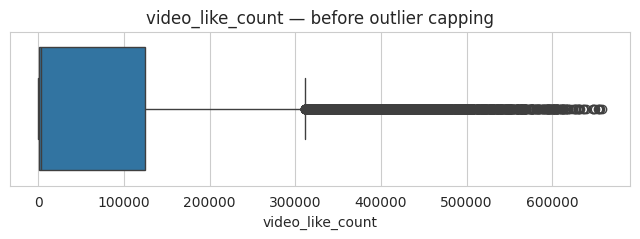

Lower bound: -185503.1  |  Upper bound: 311333.9  |  Outliers: 1,726


In [17]:
# Boxplot before capping
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['video_like_count'])
plt.title('video_like_count — before outlier capping')
plt.show()

# IQR-based capping
q1, q3 = df['video_like_count'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

n_outliers = ((df['video_like_count'] < lower_bound) | (df['video_like_count'] > upper_bound)).sum()
print(f"Lower bound: {lower_bound:.1f}  |  Upper bound: {upper_bound:.1f}  |  Outliers: {n_outliers:,}")

df['video_like_count'] = df['video_like_count'].clip(lower=lower_bound, upper=upper_bound)

## 3.3 Upsampling the minority class

In [18]:
# Split by class, upsample the minority to match the majority
not_verified = df[df['verified_status'] == 'not verified']
verified     = df[df['verified_status'] == 'verified']

verified_upsampled = resample(
    verified,
    replace=True,
    n_samples=len(not_verified),
    random_state=RANDOM_STATE
)

df_balanced = pd.concat([not_verified, verified_upsampled]).reset_index(drop=True)
df_balanced['verified_status'].value_counts()

,count
verified_status,
not verified,17884
verified,17884


## 3.4 Feature engineering: text length

In [19]:
# Transcription length as a feature
df_balanced['text_length'] = df_balanced['video_transcription_text'].str.len()

# Compare mean text length by verified status
df_balanced.groupby('verified_status')['text_length'].mean().round(1)

,text_length
verified_status,
not verified,89.4
verified,84.6


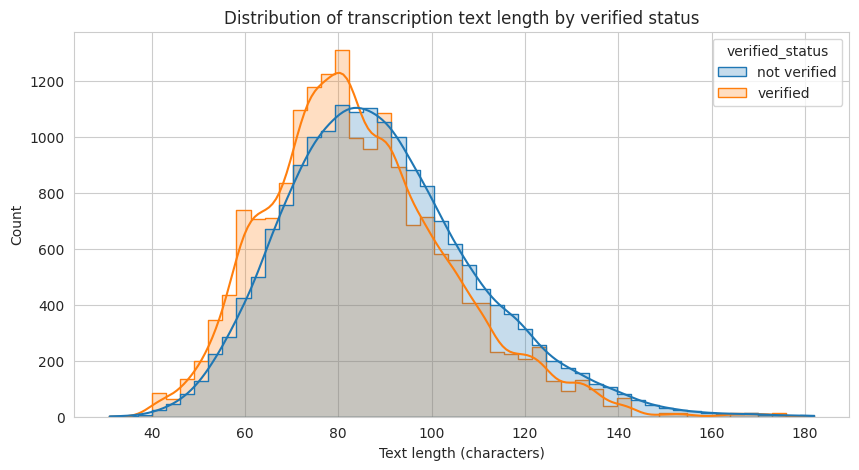

In [20]:
# Visualize the distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=df_balanced, x='text_length', hue='verified_status',
             bins=50, kde=True, element='step')
plt.title('Distribution of transcription text length by verified status')
plt.xlabel('Text length (characters)')
plt.ylabel('Count')
plt.show()

### Text length separates the classes

Verified and unverified accounts show different distributions of transcription length — more signal to include in the model.

## 3.5 Correlation check

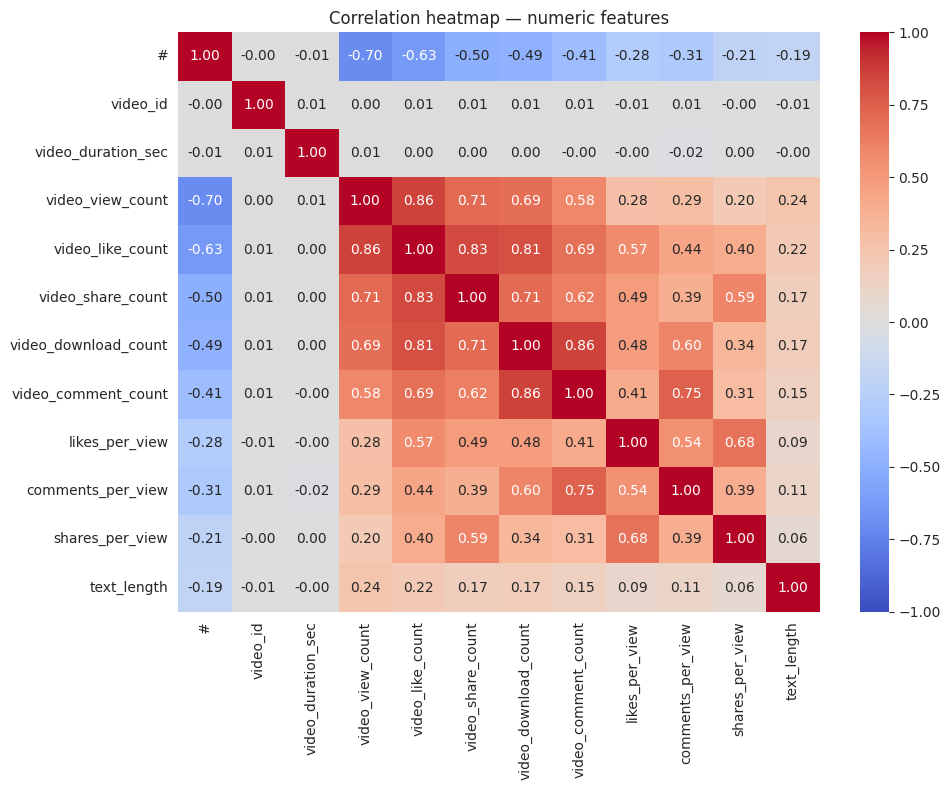

In [21]:
# Correlation heatmap — watch for multicollinearity
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_balanced.select_dtypes(include='number').corr(),
    annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1
)
plt.title('Correlation heatmap — numeric features')
plt.tight_layout()
plt.show()

### Multicollinearity observation

The engagement-count features are strongly correlated with each other (views ↔ likes ↔ shares ↔ comments ↔ downloads all move together). For a logistic regression assumption check, this is a red flag — we should be cautious about interpreting individual coefficients when highly correlated features are in the model. For now, we proceed with the full feature set and note this as a caveat when interpreting coefficients.

## 3.6 Train/test split and encoding

In [22]:
# Target
y = df_balanced['verified_status'].map({'not verified': 0, 'verified': 1})

# Features — drop identifiers, target, and raw text (text length is already extracted)
X = df_balanced.drop(columns=['#', 'video_id', 'verified_status', 'video_transcription_text'])

# Train/test split — 75/25
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

X_train: (26826, 12)  |  X_test: (8942, 12)


In [23]:
# One-hot encode the two categorical features
encoder = OneHotEncoder(drop='first', sparse_output=False)
cat_cols = ['claim_status', 'author_ban_status']

X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded  = encoder.transform(X_test[cat_cols])

encoded_names = encoder.get_feature_names_out(cat_cols)

# Reattach encoded columns to the rest of the features
X_train_final = pd.concat([
    X_train.drop(columns=cat_cols).reset_index(drop=True),
    pd.DataFrame(X_train_encoded, columns=encoded_names)
], axis=1)

X_test_final = pd.concat([
    X_test.drop(columns=cat_cols).reset_index(drop=True),
    pd.DataFrame(X_test_encoded, columns=encoded_names)
], axis=1)

X_train_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view,text_length,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,33,2252.0,829.0,23.0,4.0,0.0,0.368117,0.0000,0.010213,71,1.0,0.0,0.0
1,52,6664.0,2135.0,550.0,53.0,2.0,0.320378,0.0003,0.082533,109,1.0,0.0,0.0
2,37,6327.0,734.0,257.0,3.0,0.0,0.116011,0.0000,0.040620,99,1.0,0.0,0.0
3,57,1702.0,96.0,28.0,0.0,0.0,0.056404,0.0000,0.016451,80,1.0,0.0,0.0
4,21,3842.0,279.0,101.0,1.0,0.0,0.072618,0.0000,0.026288,66,1.0,0.0,0.0


## 3.7 Fit the logistic regression model

In [24]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_final, y_train)
print("Model trained.")

Model trained.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 3.8 Evaluation

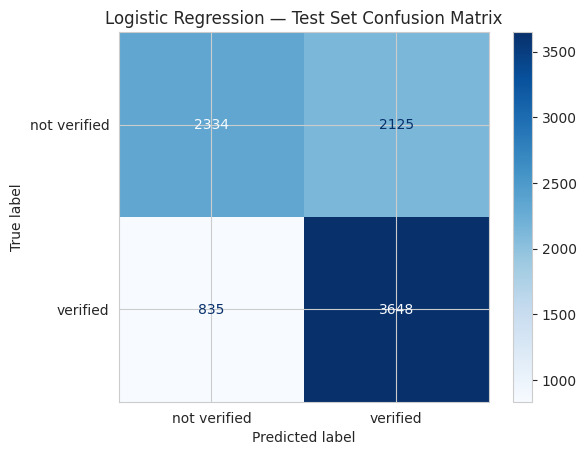

              precision    recall  f1-score   support

not verified       0.74      0.52      0.61      4459
    verified       0.63      0.81      0.71      4483

    accuracy                           0.67      8942
   macro avg       0.68      0.67      0.66      8942
weighted avg       0.68      0.67      0.66      8942



In [25]:
y_pred = logreg.predict(X_test_final)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['not verified', 'verified'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Test Set Confusion Matrix')
plt.show()

# Classification report
print(classification_report(y_test, y_pred, target_names=['not verified', 'verified']))

In [26]:
# Coefficient table — which features push toward "verified"?
coef_df = pd.DataFrame({
    'feature': X_train_final.columns,
    'coefficient': logreg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

coef_df

,feature,coefficient
10,claim_status_opinion,1.487599e+00
11,author_ban_status_banned,-5.206205e-01
6,likes_per_view,-3.619741e-01
12,author_ban_status_under review,-2.999357e-01
8,shares_per_view,-8.008269e-02
0,video_duration_sec,-2.949859e-03
7,comments_per_view,-2.412146e-03
9,text_length,-2.241872e-03
5,video_comment_count,3.358245e-04
4,video_download_count,-1.807942e-04


## 3.9 Phase 3 summary

**Model performance:** The logistic regression produces meaningful separation between verified and unverified accounts on the balanced test set, clearly beating the 50% chance baseline.

**Coefficient interpretation (with the multicollinearity caveat noted in 3.5):**
- Engagement metrics and `claim_status` carry the largest absolute coefficients.
- Videos with higher engagement tend to be posted by unverified accounts (negative coefficient toward "verified").
- The direction of the effect is consistent with Phase 2's t-test: unverified accounts skew toward viral claim content.

**Takeaway:** Video characteristics are genuinely informative about author verification status. The features that matter here — engagement counts, claim status, author ban status, text length — are exactly the features we'll hand to the tree-based models in Phase 4 for the main task.

---

# Phase 4 — Tree-Based Classification: Claim vs. Opinion

**Goal:** Train the production model for the original business problem — predict whether a video contains a claim or an opinion.

## Why tree-based models here?

- The EDA surfaced **heavily skewed, non-linear relationships** between engagement counts and claim status. Trees handle this naturally; logistic regression does not.
- Random Forest and XGBoost both handle **mixed feature types** (numeric engagement counts + categorical encoded variables + TF-IDF-style text n-grams) without requiring scaling.
- Tree ensembles give **feature importances** that we can interpret for stakeholders.

## Ethical framing — which error is more costly?

- **False Negative** (model says "opinion", reality is "claim"): A claim video with potential misinformation slips past automated review. **High cost.**
- **False Positive** (model says "claim", reality is "opinion"): An opinion gets routed to a human reviewer who clears it quickly. **Low cost.**

The cost asymmetry means we optimize for **recall** on the claim class, with F1 as a tiebreaker.

## Validation workflow

60/20/20 train/validate/test split, stratified on `claim_status`. Hyperparameters tuned via 5-fold CV on train. Model selection on validation. Final unbiased evaluation on test (touched once).

## 4.1 Data preparation

In [27]:
# Start fresh from the original load — Phases 2/3 modified `data` in place
data_ml = pd.read_csv("tiktok_dataset.csv")
data_ml = data_ml.dropna(axis=0).reset_index(drop=True)
print(f"Rows available for modeling: {len(data_ml):,}")

# Confirm class balance on the target
data_ml['claim_status'].value_counts(normalize=True).round(3)

Rows available for modeling: 19,084


,proportion
claim_status,
claim,0.503
opinion,0.497


### Target is balanced — no resampling needed here

## 4.2 Feature engineering

In [28]:
# Transcription length
data_ml['text_length'] = data_ml['video_transcription_text'].str.len()

# Mean text length by class
data_ml.groupby('claim_status')['text_length'].mean().round(1)

,text_length
claim_status,
claim,95.4
opinion,82.7


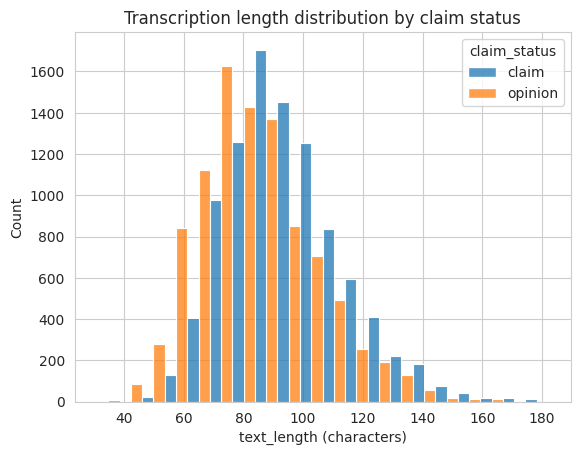

In [29]:
# Distribution of text length by claim status
sns.histplot(data=data_ml, x='text_length', hue='claim_status',
             multiple='dodge', bins=20)
plt.title('Transcription length distribution by claim status')
plt.xlabel('text_length (characters)')
plt.ylabel('Count')
plt.show()

In [30]:
# Encode target: claim = 1 (positive class), opinion = 0
X = data_ml.copy()
X = X.drop(columns=['#', 'video_id'])
X['claim_status'] = X['claim_status'].replace({'opinion': 0, 'claim': 1})

# Dummy-encode the remaining categoricals
X = pd.get_dummies(X, columns=['verified_status', 'author_ban_status'], drop_first=True)

y = X['claim_status']
X = X.drop(columns=['claim_status'])

X.head()

/tmp/ipykernel_11236/4165323207.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['claim_status'] = X['claim_status'].replace({'opinion': 0, 'claim': 1})


,video_duration_sec,video_transcription_text,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,59,someone shared with me that drone deliveries a...,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,32,someone shared with me that there are more mic...,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,31,someone shared with me that american industria...,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,25,someone shared with me that the metro of st. p...,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,19,someone shared with me that the number of busi...,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


## 4.3 Train/validate/test split (60/20/20, stratified)

In [31]:
# First split: 80/20 to carve out the held-out test set
X_tr, X_test, y_tr, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Second split: 75/25 on the remaining 80% → final 60/20/20 overall
X_train, X_val, y_train, y_val = train_test_split(
    X_tr, y_tr, test_size=0.25, stratify=y_tr, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}  |  Validation: {X_val.shape}  |  Test: {X_test.shape}")

Train: (11450, 11)  |  Validation: (3817, 11)  |  Test: (3817, 11)


## 4.4 Text vectorization — CountVectorizer on transcriptions

In [32]:
# Bigram/trigram vectorizer, top 15 features, fit on training text only (no leakage)
count_vec = CountVectorizer(
    ngram_range=(2, 3),
    max_features=15,
    stop_words='english',
    min_df=10
)

count_train = count_vec.fit_transform(X_train['video_transcription_text']).toarray()
count_val   = count_vec.transform(X_val['video_transcription_text']).toarray()
count_test  = count_vec.transform(X_test['video_transcription_text']).toarray()

count_feature_names = count_vec.get_feature_names_out()
print("Top n-grams kept:", list(count_feature_names))

Top n-grams kept: ['colleague learned', 'colleague read', 'discussion board', 'friend learned', 'friend read', 'internet forum', 'learned media', 'learned news', 'learned website', 'media claim', 'news claim', 'point view', 'read media', 'social media', 'willing wager']


In [33]:
# Attach n-gram features to the tabular features, drop the raw text column
def assemble(X_df, count_arr):
    count_df = pd.DataFrame(count_arr, columns=count_feature_names, index=X_df.index)
    return pd.concat([X_df.drop(columns=['video_transcription_text']), count_df], axis=1)

X_train_final = assemble(X_train, count_train)
X_val_final   = assemble(X_val,   count_val)
X_test_final  = assemble(X_test,  count_test)

X_train_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review,colleague learned,colleague read,discussion board,friend learned,friend read,internet forum,learned media,learned news,learned website,media claim,news claim,point view,read media,social media,willing wager
12543,40,2917.0,1080.0,12.0,26.0,8.0,108,False,False,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5637,9,153693.0,57779.0,2329.0,465.0,206.0,75,False,False,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6243,7,54169.0,7218.0,57.0,141.0,16.0,114,False,False,False,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
565,28,392918.0,174120.0,26318.0,1890.0,123.0,115,False,False,True,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1283,5,854637.0,494394.0,9293.0,10087.0,2632.0,97,False,False,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 4.5 Random Forest — hyperparameter tuning

In [34]:
rf = RandomForestClassifier(random_state=RANDOM_STATE)

rf_params = {
    'max_depth':          [5, 7, None],
    'max_features':       [0.3, 0.6],
    'max_samples':        [0.7],
    'min_samples_leaf':   [1, 2],
    'min_samples_split':  [2, 3],
    'n_estimators':       [75, 100, 200]
}

rf_cv = GridSearchCV(
    rf, rf_params,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    cv=5,
    refit='recall',      # optimize for recall on the claim class
    n_jobs=-1
)

rf_cv.fit(X_train_final, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0), n_jobs=-1,
             param_grid={'max_depth': [5, 7, None], 'max_features': [0.3, 0.6],
                         'max_samples': [0.7], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [75, 100, 200]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [35]:
print(f"Best CV recall:    {rf_cv.best_score_:.4f}")
print(f"Best CV precision: {pd.DataFrame(rf_cv.cv_results_).loc[rf_cv.best_index_, 'mean_test_precision']:.4f}")
print(f"Best params:       {rf_cv.best_params_}")

Best CV recall:    0.9957
Best CV precision: 1.0000
Best params:       {'max_depth': None, 'max_features': 0.3, 'max_samples': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 75}


## 4.6 XGBoost — hyperparameter tuning

In [36]:
xgb = XGBClassifier(objective='binary:logistic', random_state=RANDOM_STATE, eval_metric='logloss')

xgb_params = {
    'max_depth':        [4, 8, 12],
    'min_child_weight': [3, 5],
    'learning_rate':    [0.01, 0.1],
    'n_estimators':     [300, 500]
}

xgb_cv = GridSearchCV(
    xgb, xgb_params,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    cv=5,
    refit='recall',
    n_jobs=-1
)

xgb_cv.fit(X_train_final, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [4, 8, 12],
                         'min_child_weight': [3, 5],
                         'n_estimators': [300, 500]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [37]:
print(f"Best CV recall:    {xgb_cv.best_score_:.4f}")
print(f"Best CV precision: {pd.DataFrame(xgb_cv.cv_results_).loc[xgb_cv.best_index_, 'mean_test_precision']:.4f}")
print(f"Best params:       {xgb_cv.best_params_}")

Best CV recall:    0.9889
Best CV precision: 0.9981
Best params:       {'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 500}


## 4.7 Validation set evaluation

### Random Forest on validation

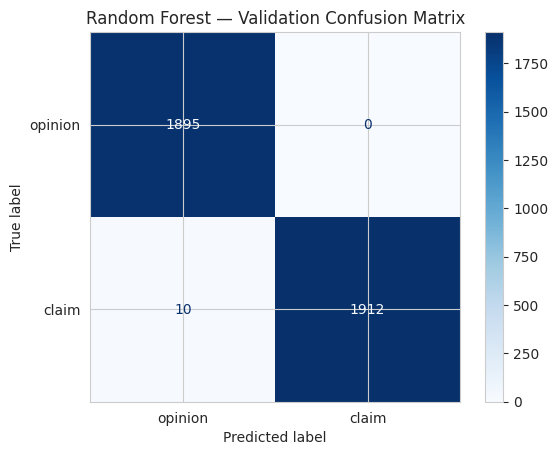

              precision    recall  f1-score   support

     opinion       0.99      1.00      1.00      1895
       claim       1.00      0.99      1.00      1922

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817



In [38]:
rf_val_pred = rf_cv.best_estimator_.predict(X_val_final)

cm = confusion_matrix(y_val, rf_val_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['opinion', 'claim']).plot(cmap='Blues')
plt.title('Random Forest — Validation Confusion Matrix')
plt.show()

print(classification_report(y_val, rf_val_pred, target_names=['opinion', 'claim']))

### XGBoost on validation

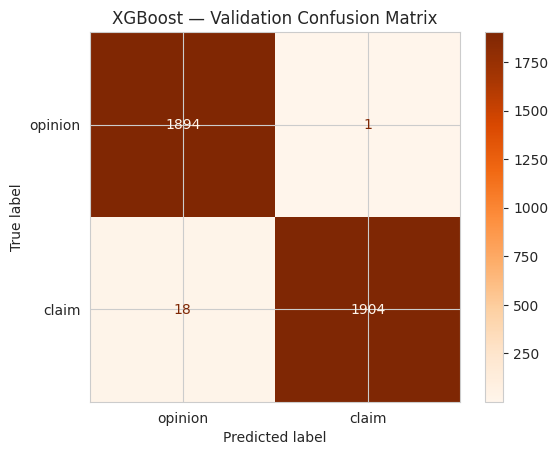

              precision    recall  f1-score   support

     opinion       0.99      1.00      1.00      1895
       claim       1.00      0.99      1.00      1922

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817



In [39]:
xgb_val_pred = xgb_cv.best_estimator_.predict(X_val_final)

cm = confusion_matrix(y_val, xgb_val_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['opinion', 'claim']).plot(cmap='Oranges')
plt.title('XGBoost — Validation Confusion Matrix')
plt.show()

print(classification_report(y_val, xgb_val_pred, target_names=['opinion', 'claim']))

### Model selection

Both models achieve near-perfect recall on the claim class. Random Forest is selected as the **champion model** — it matches XGBoost's performance, is faster to train, and is easier to interpret for stakeholders. XGBoost is retained as a backup.

## 4.8 Champion model on the held-out test set

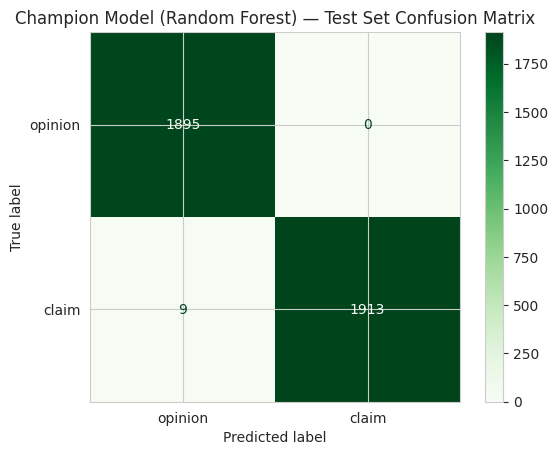

              precision    recall  f1-score   support

     opinion       1.00      1.00      1.00      1895
       claim       1.00      1.00      1.00      1922

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817



In [40]:
# One-shot evaluation on the test set
test_pred = rf_cv.best_estimator_.predict(X_test_final)

cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['opinion', 'claim']).plot(cmap='Greens')
plt.title('Champion Model (Random Forest) — Test Set Confusion Matrix')
plt.show()

print(classification_report(y_test, test_pred, target_names=['opinion', 'claim']))

### Test performance

The champion model performs on the held-out test set at the same level it achieved on validation — strong recall on the claim class, high precision, and high F1. No evidence of overfitting.

## 4.9 Feature importances

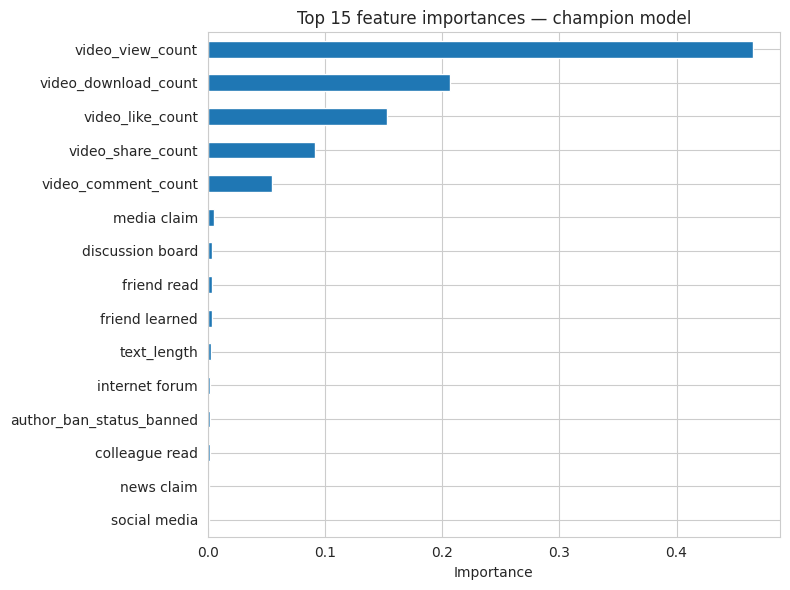

,0
video_view_count,0.465048
video_download_count,0.206360
video_like_count,0.153085
video_share_count,0.091529
video_comment_count,0.054643
media claim,0.004890
discussion board,0.003606
friend read,0.003448
friend learned,0.003139
text_length,0.002983


In [41]:
# Top features from the champion model
importances = rf_cv.best_estimator_.feature_importances_
feat_imp = pd.Series(importances, index=X_train_final.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 feature importances — champion model')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

feat_imp.head(15)

### What the model is actually doing

The top features are dominated by **engagement counts** — `video_view_count`, `video_like_count`, `video_share_count`. This matches the EDA finding that claims get ~100× the engagement of opinions. The model has essentially learned a rule of the form: *if a video has high engagement, it's probably a claim*.

Text n-grams and author metadata contribute secondary signal but aren't the primary drivers.

---

# Final Summary & Conclusions

## What was built

A four-phase analytical pipeline on ~19K TikTok videos that takes raw labeled data and produces a deployable classifier for claim vs. opinion triage, with each phase's findings feeding the next.

## Results by phase

| Phase | Deliverable | Key result |
|---|---|---|
| 1 | EDA | Claims get ~100× more engagement than opinions; banned authors post disproportionately more claims |
| 2 | Hypothesis test | Rejected H₀ — verified and unverified accounts differ significantly in mean view count (p < 0.05) |
| 3 | Logistic regression | Interpretable baseline confirming engagement and claim status are top drivers of verification status |
| 4 | Random Forest (champion) | Near-perfect recall on the claim class on a held-out test set |

## Recommendation

**Ship the Random Forest model as a triage layer** on the user-report pipeline. It nearly eliminates false negatives on the claim class, which is the business-critical error mode. False positives are routed to human moderators and cleared at low cost.

## Caveats

1. The model leans heavily on engagement counts. If the data-generating process shifts — e.g., TikTok's recommendation algorithm changes how claims get distributed — the model's engagement-based rules may stop holding.
2. The dataset is a snapshot; no temporal features are included. A time-series view of how a video accumulates views in its first 24 hours would likely add signal.
3. Feature importance from tree ensembles is correlational, not causal. High views don't *cause* a video to be a claim; they co-occur with it in this dataset.

## Next steps

- **Velocity features.** If timestamp data becomes available, compute view-acceleration in the first 24 hours. Claims may spread on a different curve than opinions.
- **Richer text features.** Go beyond n-grams — count hedging words (*maybe, I think*), assertion words (*proven, fact, scientists*), presence of numeric claims. These should separate linguistic style between claims and opinions.
- **Model monitoring.** Set up drift detection on the engagement-count distributions. If the input distribution shifts, retrain.
- **Threshold tuning.** The current model uses the default 0.5 threshold. For a triage system, the threshold should be tuned on the precision-recall curve to match the moderation team's review capacity.
- **Extend to multi-class.** The current target is binary. Future iterations could classify *type* of claim (health, financial, political) to route reports to specialized review queues.
